# Proyecto de Machine Learning
## Predicción del precio de seguros para mascotas

Este notebook funciona como **punto de entrada y resumen ejecutivo** del proyecto. Integra los resultados obtenidos en:

1. `01_preprocessing.ipynb` — limpieza y preparación.
2. `02_modeling.ipynb` — entrenamiento y comparación.
3. `03_evaluation.ipynb` — evaluación final e interpretabilidad.

> **Objetivo principal:** predecir `precio_mensual`.  
> **Objetivo secundario:** identificar las variables con mayor influencia en el precio.

**Equipo:** Angélica Sánchez, Hugo sanz y Carlos Sancho
**Proyecto:** Bootcamp Data Science


# 1. Contexto de negocio

La empresa necesita comprender cómo las características de la mascota, el plan y las coberturas influyen en el precio del seguro.

Se plantea un problema de **aprendizaje supervisado de regresión**:

- Variable objetivo: `precio_mensual`.
- Predictores: características de la mascota, raza, edad, especie, esterilización, ubicación, plan y capitales.
- Salida: valor numérico continuo.
- Criterios: rendimiento predictivo e interpretabilidad para negocio.


# 2. Flujo del proyecto

| Etapa | Notebook | Resultado |
|---|---|---|
| Preprocesamiento | `01_preprocessing.ipynb` | Dataset limpio y codificado |
| Modelado | `02_modeling.ipynb` | Modelos entrenados y train/test |
| Evaluación | `03_evaluation.ipynb` | Métricas, interpretabilidad y modelo final |

Este notebook **no repite el entrenamiento completo**. Carga los artefactos generados y presenta una visión integrada.


# 3. Importación de librerías

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
np.set_printoptions(suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)


# 4. Configuración de rutas

`main.ipynb` se encuentra en la raíz del repositorio, por lo que las rutas se construyen desde `src/`.


In [2]:
RUTA_PROYECTO = Path(".")
RUTA_NOTEBOOKS = RUTA_PROYECTO / "src" / "notebooks"
RUTA_DATA = RUTA_PROYECTO / "src" / "data"
RUTA_MODELS = RUTA_PROYECTO / "src" / "models"
RUTA_IMG = RUTA_PROYECTO / "src" / "img"

rutas = {
    "Notebook 01": RUTA_NOTEBOOKS / "01_preprocessing.ipynb",
    "Notebook 02": RUTA_NOTEBOOKS / "02_modeling.ipynb",
    "Notebook 03": RUTA_NOTEBOOKS / "03_evaluation.ipynb",
    "Dataset preprocesado": RUTA_DATA / "matriz_cotizaciones_grupos_preprocesada.csv",
    "X_train": RUTA_DATA / "X_train.pkl",
    "X_test": RUTA_DATA / "X_test.pkl",
    "y_train": RUTA_DATA / "y_train.pkl",
    "y_test": RUTA_DATA / "y_test.pkl",
    "Modelo final": RUTA_MODELS / "modelo_final.pkl",
}

estado_archivos = pd.DataFrame(
    {
        "Ruta": [str(ruta) for ruta in rutas.values()],
        "Disponible": [ruta.exists() for ruta in rutas.values()],
    },
    index=rutas.keys(),
)
estado_archivos


,Ruta,Disponible
Notebook 01,src\notebooks\01_preprocessing.ipynb,True
Notebook 02,src\notebooks\02_modeling.ipynb,True
Notebook 03,src\notebooks\03_evaluation.ipynb,True
Dataset preprocesado,src\data\matriz_cotizaciones_grupos_preprocesa...,True
X_train,src\data\X_train.pkl,True
X_test,src\data\X_test.pkl,True
y_train,src\data\y_train.pkl,True
y_test,src\data\y_test.pkl,True
Modelo final,src\models\modelo_final.pkl,True


## Comprobación previa

Todos los elementos deben aparecer como `True`. Si falta alguno, ejecutar en este orden:

1. `01_preprocessing.ipynb`
2. `02_modeling.ipynb`
3. `03_evaluation.ipynb`
4. Volver a ejecutar `main.ipynb`


# 5. Resumen del preprocesamiento

El dataset original contiene **67.500 cotizaciones y 24 variables**.

Decisiones principales:

- Eliminación de identificadores y variables técnicas.
- Eliminación de variables redundantes.
- Exclusión de `precio_anual` para evitar **data leakage**.
- Transformación de variables binarias y ordinales.
- Codificación *one-hot* de variables categóricas.
- Eliminación de la fecha, ya que el histórico disponible cubre solo once días.
- Validación final de nulos, duplicados y tipos.

Resultado: **67.500 filas y 79 columnas**, incluida la variable objetivo.


In [3]:
ruta_dataset = rutas["Dataset preprocesado"]

if not ruta_dataset.exists():
    raise FileNotFoundError(
        "No se encontró el dataset preprocesado. "
        "Ejecuta primero src/notebooks/01_preprocessing.ipynb."
    )

df_modelado = pd.read_csv(ruta_dataset)

resumen_dataset = pd.DataFrame({
    "Indicador": [
        "Número de registros",
        "Número de columnas",
        "Valores nulos",
        "Registros duplicados",
        "Variable objetivo disponible",
    ],
    "Resultado": [
        df_modelado.shape[0],
        df_modelado.shape[1],
        int(df_modelado.isna().sum().sum()),
        int(df_modelado.duplicated().sum()),
        "precio_mensual" in df_modelado.columns,
    ],
})
resumen_dataset


,Indicador,Resultado
0,Número de registros,67500
1,Número de columnas,79
2,Valores nulos,0
3,Registros duplicados,0
4,Variable objetivo disponible,True


# 6. Modelos evaluados

División **80/20**:

- Train: 54.000 registros.
- Test: 13.500 registros.

Modelos:

- Baseline (`DummyRegressor`)
- Regresión Lineal
- Ridge
- Lasso
- Elastic Net
- Random Forest

La comparación inicial se realizó mediante validación cruzada de cinco particiones sobre train.


In [5]:
from sklearn.model_selection import train_test_split

TARGET = "precio_mensual"
RANDOM_STATE = 42

# El dataset preprocesado ya se cargó anteriormente como df_modelado
X = df_modelado.drop(columns=[TARGET])
y = df_modelado[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

pd.DataFrame(
    {
        "Conjunto": ["X_train", "X_test", "y_train", "y_test"],
        "Dimensiones": [
            str(X_train.shape),
            str(X_test.shape),
            str(y_train.shape),
            str(y_test.shape),
        ],
    }
)

,Conjunto,Dimensiones
0,X_train,"(54000, 78)"
1,X_test,"(13500, 78)"
2,y_train,"(54000,)"
3,y_test,"(13500,)"


# 7. Evaluación comparativa

| Métrica | Interpretación |
|---|---|
| MAE | Error medio absoluto en euros |
| RMSE | Penaliza más los errores grandes |
| R² | Proporción de variabilidad explicada |
| MAPE | Error porcentual medio |


In [6]:
rutas_modelos = {
    "Baseline (media)": RUTA_MODELS / "baseline.pkl",
    "Regresión Lineal": RUTA_MODELS / "linear_regression.pkl",
    "Ridge": RUTA_MODELS / "ridge.pkl",
    "Lasso": RUTA_MODELS / "lasso.pkl",
    "Elastic Net": RUTA_MODELS / "elastic_net.pkl",
    "Random Forest": RUTA_MODELS / "random_forest.pkl",
}

faltantes = [nombre for nombre, ruta in rutas_modelos.items() if not ruta.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan modelos del Notebook 02: " + ", ".join(faltantes)
    )

modelos = {nombre: joblib.load(ruta) for nombre, ruta in rutas_modelos.items()}
print("Modelos cargados:", list(modelos.keys()))


Modelos cargados: ['Baseline (media)', 'Regresión Lineal', 'Ridge', 'Lasso', 'Elastic Net', 'Random Forest']


In [7]:
def calcular_metricas(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

resultados = []
for nombre, modelo in modelos.items():
    metricas = calcular_metricas(y_test, modelo.predict(X_test))
    metricas["Modelo"] = nombre
    resultados.append(metricas)

tabla_resultados = (
    pd.DataFrame(resultados)
    .set_index("Modelo")
    .sort_values("MAE")
    .round(4)
)
tabla_resultados


,MAE,RMSE,R2,MAPE (%)
Modelo,,,,
Random Forest,0.2305,0.4764,0.9980,0.6708
Ridge,1.7509,2.3437,0.9509,5.5421
Regresión Lineal,1.7515,2.3441,0.9509,5.5449
Elastic Net,5.5917,7.3887,0.5125,17.2814
Lasso,5.7620,7.6460,0.4779,17.8594
Baseline (media),8.3600,10.5821,-0.0000,27.6380


## Lectura de resultados

- **Baseline:** no explica la variabilidad.
- **Lasso y Elastic Net:** mejoran el baseline, pero su capacidad explicativa es limitada.
- **Regresión Lineal y Ridge:** alcanzan un R² cercano al 95 %.
- **Random Forest:** obtiene el menor error y un R² de 0,998.

La selección se realiza automáticamente a partir del menor MAE.


In [8]:
mejor_modelo_nombre = tabla_resultados.index[0]
mejor_modelo = modelos[mejor_modelo_nombre]
y_pred_mejor = mejor_modelo.predict(X_test)

print(f"Modelo seleccionado: {mejor_modelo_nombre}")
display(tabla_resultados.loc[[mejor_modelo_nombre]])


Modelo seleccionado: Random Forest


,MAE,RMSE,R2,MAPE (%)
Modelo,,,,
Random Forest,0.2305,0.4764,0.998,0.6708


# 8. Rendimiento visual

La nube debe situarse cerca de la diagonal de predicción perfecta.


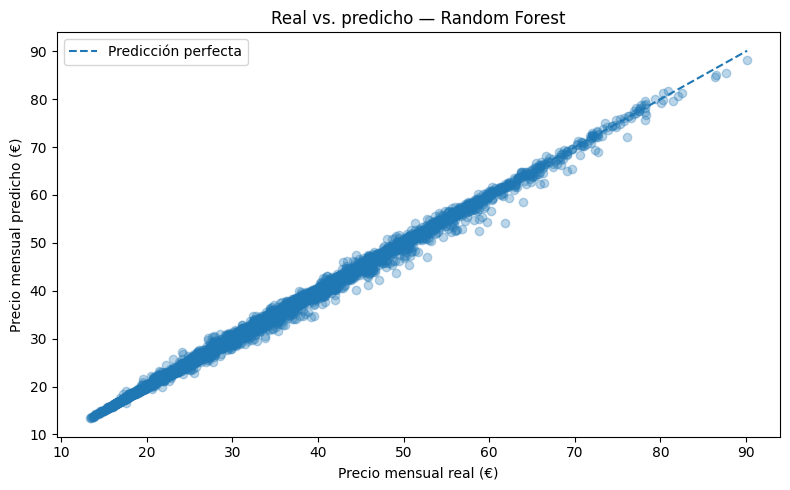

In [9]:
plt.scatter(y_test, y_pred_mejor, alpha=0.3)

limites = [
    min(y_test.min(), y_pred_mejor.min()),
    max(y_test.max(), y_pred_mejor.max()),
]

plt.plot(limites, limites, linestyle="--", label="Predicción perfecta")
plt.xlabel("Precio mensual real (€)")
plt.ylabel("Precio mensual predicho (€)")
plt.title(f"Real vs. predicho — {mejor_modelo_nombre}")
plt.legend()
plt.tight_layout()
plt.show()


# 9. Revisión de sobreajuste

Se compara el R² en train y test. Una diferencia pequeña indica un comportamiento estable sobre datos no vistos.


In [10]:
r2_train = r2_score(y_train, mejor_modelo.predict(X_train))
r2_test = r2_score(y_test, y_pred_mejor)

comparacion_generalizacion = pd.DataFrame({
    "R2_train": [r2_train],
    "R2_test": [r2_test],
    "Diferencia": [r2_train - r2_test],
}, index=[mejor_modelo_nombre]).round(4)

comparacion_generalizacion


,R2_train,R2_test,Diferencia
Random Forest,0.9997,0.998,0.0018


## Interpretación

Resultados aproximados:

- R² train: **0,9997**
- R² test: **0,9980**
- Diferencia: **0,0018**

No se observa sobreajuste relevante. Además, `precio_anual` fue eliminada para prevenir data leakage.


# 10. Variables con mayor influencia

Las importancias responden al segundo objetivo del negocio. Representan contribución predictiva, no causalidad.


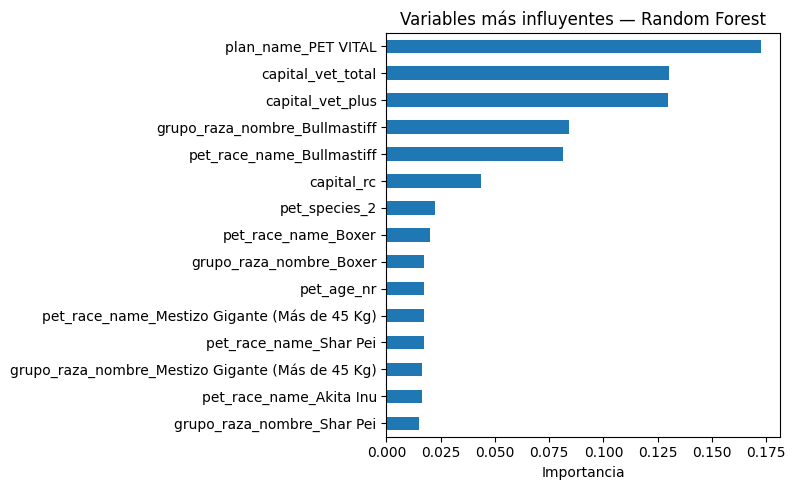

,Importancia
plan_name_PET VITAL,0.172732
capital_vet_total,0.130322
capital_vet_plus,0.129959
grupo_raza_nombre_Bullmastiff,0.084098
pet_race_name_Bullmastiff,0.081428
capital_rc,0.043372
pet_species_2,0.022406
pet_race_name_Boxer,0.020148
grupo_raza_nombre_Boxer,0.017477
pet_age_nr,0.017403


In [11]:
if not hasattr(mejor_modelo, "feature_importances_"):
    raise AttributeError(
        f"El modelo {mejor_modelo_nombre} no expone feature_importances_."
    )

importancias = (
    pd.Series(
        mejor_modelo.feature_importances_,
        index=X_test.columns,
        name="Importancia",
    )
    .sort_values(ascending=False)
)

top_importancias = importancias.head(15)

top_importancias.sort_values().plot(kind="barh")
plt.title(f"Variables más influyentes — {mejor_modelo_nombre}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

top_importancias.to_frame()


## Lectura para negocio

Los factores con mayor capacidad predictiva se concentran en:

- Plan contratado.
- Capitales de cobertura veterinaria.
- Responsabilidad civil.
- Raza o grupo de raza.
- Especie y edad.

Algunas categorías aparecen desdobladas por el *one-hot encoding*. Para negocio conviene agruparlas por concepto.


# 11. Modelo final

El Notebook 03 guarda el modelo definitivo en:

```text
src/models/modelo_final.pkl
```

Esto permite reutilizarlo sin repetir el entrenamiento.


In [12]:
ruta_modelo_final = rutas["Modelo final"]

if ruta_modelo_final.exists():
    modelo_final = joblib.load(ruta_modelo_final)
    print(f"Modelo final disponible: {type(modelo_final).__name__}")
    print(f"Ruta: {ruta_modelo_final}")
else:
    print(
        "El archivo modelo_final.pkl no existe todavía. "
        "Ejecuta src/notebooks/03_evaluation.ipynb."
    )


Modelo final disponible: RandomForestRegressor
Ruta: src\models\modelo_final.pkl


# 12. Conclusiones finales

## Modelo seleccionado

**Random Forest**

Resultados sobre test:

- **MAE:** 0,23 €
- **RMSE:** 0,48 €
- **R²:** 0,998
- **MAPE:** 0,67 %

## Respuesta al negocio

El proyecto permite:

1. Estimar el precio mensual con un error medio muy reducido.
2. Identificar los factores con mayor influencia predictiva.
3. Disponer de un modelo persistido y reutilizable.
4. Comparar el modelo ganador con alternativas lineales y un baseline.

## Consideración metodológica

El dataset se construye mediante combinaciones controladas de perfiles y coberturas. El elevado R² es coherente con su estructura, pero no garantiza el mismo rendimiento sobre cotizaciones reales externas.

## Próximos pasos

- Validar con cotizaciones reales externas.
- Ampliar el histórico temporal.
- Revisar periódicamente posibles cambios en las reglas de tarificación.
- Agrupar variables codificadas para facilitar la interpretación.


# 13. Estructura del repositorio

```text
proyecto-ml-seguros-mascotas/
│
├── main.ipynb
├── README.md
├── requirements.txt
│
└── src/
    ├── data/
    ├── img/
    ├── models/
    └── notebooks/
        ├── 01_preprocessing.ipynb
        ├── 02_modeling.ipynb
        └── 03_evaluation.ipynb
```

## Orden de ejecución

1. `src/notebooks/01_preprocessing.ipynb`
2. `src/notebooks/02_modeling.ipynb`
3. `src/notebooks/03_evaluation.ipynb`
4. `main.ipynb`


# Fin del proyecto

El flujo completo del proyecto ha sido ejecutado y validado correctamente.

Los notebooks especializados contienen el detalle técnico de cada fase:

- 01_preprocessing.ipynb
- 02_modeling.ipynb
- 03_evaluation.ipynb

Este notebook resume el trabajo realizado y presenta los resultados finales del modelo seleccionado.